# Tutorial 03 -- Cavity Displacement Basics

Create coherent states with `build_displacement_pulse(...)`, verify the expected cavity amplitude, and visualize the final storage state in phase space.

**Prerequisites.** Tutorials 01 and 02 are recommended first.


## 1. Goal

We will start from vacuum, apply calibrated displacement pulses, and compare the simulated cavity moments to the requested coherent-state amplitudes.


## 2. Physical Background

A displacement pulse moves the cavity state in phase space. In the rotating frame, the ideal target is a coherent state `|alpha>`, whose mean field satisfies `<a> = alpha` and whose mean photon number is `|alpha|^2`.


## 3. Imports


In [1]:
from __future__ import annotations

from functools import partial
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from cqed_sim import (
    AmplifierChain,
    BosonicModeSpec,
    DispersiveCouplingSpec,
    DispersiveReadoutTransmonStorageModel,
    DispersiveTransmonCavityModel,
    DisplacementGate,
    FrameSpec,
    NoiseSpec,
    Pulse,
    PurcellFilter,
    QubitMeasurementSpec,
    ReadoutChain,
    ReadoutResonator,
    RotationGate,
    SidebandDriveSpec,
    SequenceCompiler,
    SimulationConfig,
    StatePreparationSpec,
    TransmonModeSpec,
    UniversalCQEDModel,
    build_displacement_pulse,
    build_rotation_pulse,
    build_sideband_pulse,
    carrier_for_transition_frequency,
    coherent_state,
    compute_energy_spectrum,
    fock_state,
    manifold_transition_frequency,
    measure_qubit,
    prepare_simulation,
    prepare_state,
    pure_dephasing_time_from_t1_t2,
    qubit_state,
    run_rabi,
    run_ramsey,
    run_spectroscopy,
    run_t1,
    run_t2_echo,
    sideband_transition_frequency,
    simulate_batch,
    simulate_sequence,
)
from cqed_sim.plotting import plot_energy_levels
from cqed_sim.pulses import gaussian_envelope, square_envelope
from cqed_sim.sim import (
    cavity_wigner,
    conditioned_bloch_xyz,
    mode_moments,
    qubit_conditioned_mode_moments,
    readout_response_by_qubit_state,
    reduced_cavity_state,
    reduced_qubit_state,
    reduced_storage_state,
    storage_photon_number,
    subsystem_level_population,
    transmon_level_populations,
)
from tutorials.tutorial_support import (
    GHz,
    MHz,
    angular_to_ghz,
    angular_to_hz,
    angular_to_mhz,
    cross_kerr_conditional_phase,
    final_expectation,
    fit_echo_signal,
    fit_exponential_decay,
    fit_lorentzian_peak,
    fit_rabi_vs_amplitude,
    fit_rabi_vs_duration,
    fit_ramsey_signal,
    gaussian_quasistatic_echo_excited_population,
    gaussian_quasistatic_ramsey_excited_population,
    ns,
    ramsey_population,
    resonant_drive_excited_population,
    t1_relaxation_population,
    us,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (7.0, 4.2)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 4. Simulation Parameters


In [2]:
alpha_targets = [0.5 + 0.0j, 1.0 + 0.0j, 1.5 + 0.0j]
displacement_duration = 120.0 * ns
dt = 2.0 * ns


## 5. Model Construction


In [3]:
model = DispersiveTransmonCavityModel(
    omega_c=GHz(5.1),
    omega_q=GHz(6.2),
    alpha=MHz(-220.0),
    chi=0.0,
    kerr=0.0,
    n_cav=20,
    n_tr=2,
)
frame = FrameSpec(omega_c_frame=model.omega_c, omega_q_frame=model.omega_q)
initial_state = model.basis_state(0, 0)


## 6. Pulse / Sequence Construction


In [4]:
displacement_jobs = []
for alpha in alpha_targets:
    pulses, drive_ops, meta = build_displacement_pulse(
        DisplacementGate(index=0, name=f"D({alpha.real:+.2f}{alpha.imag:+.2f}i)", re=float(np.real(alpha)), im=float(np.imag(alpha))),
        {"duration_displacement_s": displacement_duration},
    )
    displacement_jobs.append((alpha, pulses, drive_ops, meta))


## 7. Running the Simulation


In [5]:
results = []
for alpha, pulses, drive_ops, meta in displacement_jobs:
    compiled = SequenceCompiler(dt=dt).compile(pulses, t_end=displacement_duration + dt)
    result = simulate_sequence(
        model,
        compiled,
        initial_state,
        drive_ops,
        config=SimulationConfig(frame=frame),
    )
    moments = mode_moments(result.final_state, "storage")
    results.append(
        {
            "target_alpha": alpha,
            "simulated_alpha": moments["a"],
            "simulated_n": moments["n"],
            "result": result,
        }
    )

for row in results:
    print(
        f"target={row['target_alpha']:+.2f}, simulated <a>={row['simulated_alpha']:+.3f}, <n>={row['simulated_n']:.3f}"
    )


target=+0.50+0.00j, simulated <a>=+0.495+0.000j, <n>=0.245
target=+1.00+0.00j, simulated <a>=+0.990+0.000j, <n>=0.979
target=+1.50+0.00j, simulated <a>=+1.484+0.000j, <n>=2.204


## 8. Visualizing the Results


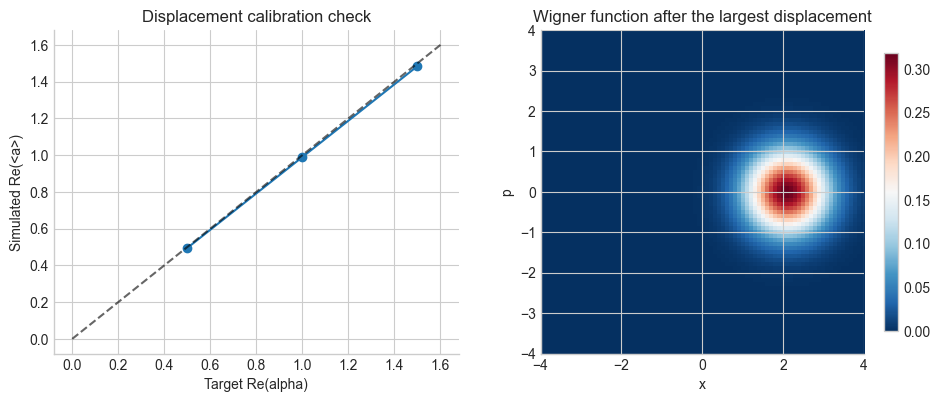

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
axes[0].plot([np.real(row["target_alpha"]) for row in results], [np.real(row["simulated_alpha"]) for row in results], "o-")
axes[0].plot([0.0, 1.6], [0.0, 1.6], "--", color="black", alpha=0.6)
axes[0].set_xlabel("Target Re(alpha)")
axes[0].set_ylabel("Simulated Re(<a>)")
axes[0].set_title("Displacement calibration check")

chosen_state = reduced_cavity_state(results[-1]["result"].final_state)
xvec, yvec, w = cavity_wigner(chosen_state, n_points=81, extent=4.0)
image = axes[1].imshow(w, origin="lower", extent=[xvec[0], xvec[-1], yvec[0], yvec[-1]], cmap="RdBu_r", aspect="equal")
axes[1].set_xlabel("x")
axes[1].set_ylabel("p")
axes[1].set_title("Wigner function after the largest displacement")
fig.colorbar(image, ax=axes[1], shrink=0.86)
plt.show()


## 9. Physical Interpretation

The near-identity line between target `alpha` and simulated `<a>` confirms that the public displacement builder is already calibrated in the rotating frame. The Wigner function stays Gaussian because the model here has negligible Kerr during the short pulse.


## 10. Exercises / Next Steps

- Repeat the scan with a complex displacement such as `alpha = 1.0 + 0.8j`.
- Add a small nonzero Kerr and make the pulse much longer to see where the ideal coherent-state picture starts to bend.
- Continue to Tutorial 05 for more state and observable extraction tools.
